              precision    recall  f1-score   support

           0       0.56      0.59      0.58       105
           1       0.52      0.49      0.51        95

    accuracy                           0.55       200
   macro avg       0.54      0.54      0.54       200
weighted avg       0.54      0.55      0.54       200



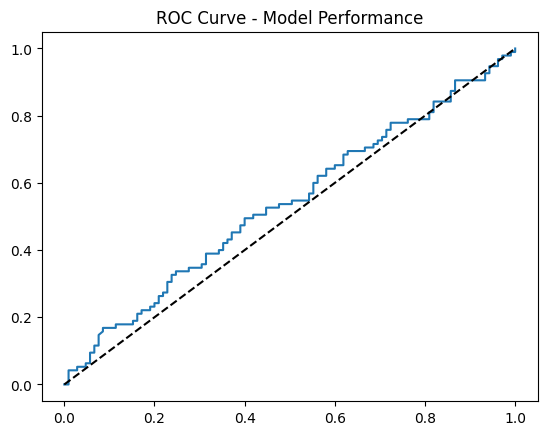

TypeError: unsupported operand type(s) for /: 'str' and 'int'

In [1]:
# day 48 Production level code 
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_curve, auc
from xgboost import XGBClassifier

n = 1000
df = pl.DataFrame({
    "tenure": np.random.randint(1, 72, n),
    "monthly_charges": np.random.uniform(20, 120, n),
    "total_charges": np.random.uniform(100, 8000, n),
    "contract": np.random.choice(["Month", "OneYear", "TwoYear"], n),
    "churn": np.random.randint(0, 2, n)
})

df = df.with_columns((pl.col("total_charges") / pl.col("tenure")).alias("avg_monthly_rev"))

X = df.drop("churn").to_pandas()
y = df["churn"].to_numpy()

num_cols = ["tenure", "monthly_charges", "total_charges", "avg_monthly_rev"]
cat_cols = ["contract"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(eval_metric='logloss'))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {"clf__n_estimators": [50, 100], "clf__max_depth": [3, 5]}
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
joblib.dump(best_model, "models/churn_model.pkl")

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))

fpr, tpr, _ = roc_curve(y_test, probs)
plt.plot(fpr, tpr, label=f"AUC: {auc(fpr, tpr):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Model Performance")
plt.show()

sns.heatmap(df.corr().to_pandas(), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
import os
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_curve, auc
from xgboost import XGBClassifier

os.makedirs("models", exist_ok=True)
os.makedirs("output", exist_ok=True)

n = 1000
df = pl.DataFrame({
    "tenure": np.random.randint(1, 72, n),
    "monthly_charges": np.random.uniform(20, 120, n),
    "total_charges": np.random.uniform(100, 8000, n),
    "contract": np.random.choice(["Month", "OneYear", "TwoYear"], n),
    "churn": np.random.randint(0, 2, n)
})

df = df.with_columns((pl.col("total_charges") / pl.col("tenure")).alias("avg_monthly_rev"))

X = df.drop("churn").to_pandas()
y = df["churn"].to_numpy()

num_cols = ["tenure", "monthly_charges", "total_charges", "avg_monthly_rev"]
cat_cols = ["contract"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", XGBClassifier(eval_metric='logloss', random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {"clf__n_estimators": [50, 100], "clf__max_depth": [3, 5]}
grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
joblib.dump(best_model, "models/churn_model.pkl")

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds))

# Plot and save ROC Curve
fpr, tpr, _ = roc_curve(y_test, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC: {auc(fpr, tpr):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve - Model Performance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.savefig("output/roc_curve.png")
plt.close()

# Plot and save Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr().to_pandas(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.savefig("output/correlation_heatmap.png")
plt.close()

print("Pipeline executed successfully! Artifacts saved in 'models/' and 'output/' folders.")